In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os

class Config:
    PROJECT_ROOT    = '/content/drive/MyDrive/FinDocVQA'
    FINANCIAL_IMGS  = os.path.join(PROJECT_ROOT, 'data/financial_test/images')
    FINANCIAL_ANNOT = os.path.join(PROJECT_ROOT, 'data/financial_test/annotations')
    OUTPUTS_DIR     = os.path.join(PROJECT_ROOT, 'outputs')

cfg = Config()
print("✓ Ready")

Mounted at /content/drive
✓ Ready


In [2]:
# ============================================================
# CELL 2: Install deps
# ============================================================

%%capture
!pip install requests pdf2image Pillow
!apt-get -qq install poppler-utils

In [3]:
# ============================================================
# CELL 3: Download SEC 10-K Filings and Convert to Images
# ============================================================
# We use SEC EDGAR's free public API to download 10-K filings
# from major companies, then convert specific pages to images.
#
# SEC requires a User-Agent header identifying you.
# ============================================================

import requests
import json
import time
from pathlib import Path

# SEC requires this header
HEADERS = {
    'User-Agent': 'Vishwas Kothari vishwasvikas.kothari@colorado.edu',
    'Accept-Encoding': 'gzip, deflate'
}

# Target companies — mix of sectors for diversity
COMPANIES = {
    'AAPL':  {'cik': '0000320193', 'name': 'Apple Inc'},
    'JPM':   {'cik': '0000019617', 'name': 'JPMorgan Chase'},
    'MSFT':  {'cik': '0000789019', 'name': 'Microsoft Corp'},
    'GS':    {'cik': '0000886982', 'name': 'Goldman Sachs'},
    'BAC':   {'cik': '0000070858', 'name': 'Bank of America'},
    'WMT':   {'cik': '0000104169', 'name': 'Walmart Inc'},
    'JNJ':   {'cik': '0000200406', 'name': 'Johnson & Johnson'},
    'XOM':   {'cik': '0000034088', 'name': 'Exxon Mobil'},
    'AMZN':  {'cik': '0001018724', 'name': 'Amazon'},
    'TSLA':  {'cik': '0001318605', 'name': 'Tesla Inc'},
}

def get_recent_10k_urls(cik, n=1):
    """Get URLs of recent 10-K filings from EDGAR."""
    url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    resp = requests.get(url, headers=HEADERS)
    time.sleep(0.2)  # respect rate limits

    if resp.status_code != 200:
        print(f"  Failed to fetch CIK {cik}: {resp.status_code}")
        return []

    data = resp.json()
    recent = data.get('filings', {}).get('recent', {})

    forms = recent.get('form', [])
    accessions = recent.get('accessionNumber', [])
    primary_docs = recent.get('primaryDocument', [])

    results = []
    for i, form in enumerate(forms):
        if form == '10-K' and len(results) < n:
            acc = accessions[i].replace('-', '')
            doc = primary_docs[i]
            filing_url = f"https://www.sec.gov/Archives/edgar/data/{cik.lstrip('0')}/{acc}/{doc}"
            results.append(filing_url)

    return results

# --- Fetch filing URLs ---
print("Fetching 10-K filing URLs from SEC EDGAR...")
print("=" * 60)

all_filings = {}
for ticker, info in COMPANIES.items():
    urls = get_recent_10k_urls(info['cik'], n=1)
    if urls:
        all_filings[ticker] = {
            'name': info['name'],
            'url': urls[0]
        }
        print(f"  ✓ {ticker} ({info['name']}): found 10-K")
    else:
        print(f"  ✗ {ticker}: no 10-K found")
    time.sleep(0.3)

print(f"\nFound {len(all_filings)} filings")

# Save URLs for reference
urls_path = os.path.join(cfg.FINANCIAL_ANNOT, 'filing_urls.json')
with open(urls_path, 'w') as f:
    json.dump(all_filings, f, indent=2)
print(f"✓ Saved to {urls_path}")

Fetching 10-K filing URLs from SEC EDGAR...
  ✓ AAPL (Apple Inc): found 10-K
  ✓ JPM (JPMorgan Chase): found 10-K
  ✓ MSFT (Microsoft Corp): found 10-K
  ✓ GS (Goldman Sachs): found 10-K
  ✓ BAC (Bank of America): found 10-K
  ✓ WMT (Walmart Inc): found 10-K
  ✓ JNJ (Johnson & Johnson): found 10-K
  ✓ XOM (Exxon Mobil): found 10-K
  ✓ AMZN (Amazon): found 10-K
  ✓ TSLA (Tesla Inc): found 10-K

Found 10 filings
✓ Saved to /content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/filing_urls.json


In [4]:
# ============================================================
# CELL 4: Download Filings and Convert Key Pages to Images
# ============================================================
# SEC filings are HTML. We'll download them, render specific
# pages to images using a headless approach.
# For 10-K filings, the most useful pages are:
#   - Income statements
#   - Balance sheets
#   - Cash flow statements
#   - Notes with tables
# ============================================================

import requests
import time
import os
from pathlib import Path

# First, let's see what format these filings are in
print("Checking filing formats...")
print("=" * 60)

for ticker, info in list(all_filings.items())[:3]:  # check first 3
    url = info['url']
    resp = requests.get(url, headers=HEADERS, stream=True)
    time.sleep(0.3)
    content_type = resp.headers.get('Content-Type', 'unknown')
    # Get first 200 chars to see format
    first_bytes = resp.content[:200].decode('utf-8', errors='ignore')
    is_html = '<html' in first_bytes.lower() or '<!doctype' in first_bytes.lower()
    is_pdf = first_bytes.startswith('%PDF')

    print(f"  {ticker}: {content_type}")
    print(f"    HTML: {is_html}, PDF: {is_pdf}")
    print(f"    URL: {url[:80]}...")
    print()

Checking filing formats...
  AAPL: text/html
    HTML: False, PDF: False
    URL: https://www.sec.gov/Archives/edgar/data/320193/000032019325000079/aapl-20250927....

  JPM: text/html
    HTML: False, PDF: False
    URL: https://www.sec.gov/Archives/edgar/data/19617/000162828026008131/jpm-20251231.ht...

  MSFT: text/html
    HTML: False, PDF: False
    URL: https://www.sec.gov/Archives/edgar/data/789019/000095017025100235/msft-20250630....



In [5]:
# ============================================================
# CELL 5: Download Filings as HTML, Convert to Images
# ============================================================
# Strategy: Download full HTML, save it, then use wkhtmltoimage
# to render pages as PNG images.
# ============================================================

%%capture
!apt-get -qq install wkhtmltopdf

# ---
from PIL import Image
import subprocess
import tempfile

def html_to_images(html_content, output_dir, prefix, max_pages=5):
    """Convert HTML to page images using wkhtmltoimage."""
    saved = []

    # Save HTML to temp file
    with tempfile.NamedTemporaryFile(suffix='.html', mode='w',
                                      delete=False, encoding='utf-8') as f:
        f.write(html_content)
        temp_html = f.name

    # First convert to PDF, then PDF to images
    temp_pdf = temp_html.replace('.html', '.pdf')

    try:
        # HTML → PDF
        result = subprocess.run(
            ['wkhtmltopdf', '--quiet', '--no-stop-slow-scripts',
             '--javascript-delay', '1000',
             '--page-size', 'Letter',
             temp_html, temp_pdf],
            capture_output=True, timeout=60
        )

        if os.path.exists(temp_pdf):
            # PDF → Images
            from pdf2image import convert_from_path
            images = convert_from_path(temp_pdf, dpi=200,
                                        first_page=1,
                                        last_page=max_pages)

            for i, img in enumerate(images):
                img_path = os.path.join(output_dir, f"{prefix}_page_{i+1:03d}.png")
                img.save(img_path, 'PNG')
                saved.append(img_path)

    except Exception as e:
        print(f"    Conversion error: {e}")
    finally:
        # Cleanup temp files
        for f in [temp_html, temp_pdf]:
            if os.path.exists(f):
                os.remove(f)

    return saved

# --- Download and convert each filing ---
print("Downloading and converting filings to images...")
print("=" * 60)

all_images = {}

for ticker, info in all_filings.items():
    print(f"\n  Processing {ticker} ({info['name']})...")

    # Download HTML
    resp = requests.get(info['url'], headers=HEADERS)
    time.sleep(0.5)

    if resp.status_code != 200:
        print(f"    ✗ Download failed: {resp.status_code}")
        continue

    html = resp.text
    print(f"    Downloaded: {len(html):,} chars")

    # Convert to images (first 10 pages to get financial statements)
    ticker_dir = os.path.join(cfg.FINANCIAL_IMGS, ticker)
    os.makedirs(ticker_dir, exist_ok=True)

    images = html_to_images(html, ticker_dir, ticker, max_pages=10)
    all_images[ticker] = images
    print(f"    ✓ Generated {len(images)} page images")

    time.sleep(0.5)

# Summary
total = sum(len(v) for v in all_images.values())
print(f"\n{'=' * 60}")
print(f"Total images generated: {total}")
print(f"Companies processed: {len(all_images)}")

In [7]:
# ============================================================
# CELL 7: Install Playwright + Convert Filings to Images
# ============================================================

!pip install playwright -q
!playwright install chromium -q

import asyncio
from playwright.async_api import async_playwright
from PIL import Image
import os
import time

async def html_url_to_images(url, output_dir, prefix, headers, max_pages=10):
    """Screenshot a filing URL using headless Chromium."""
    saved = []

    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page(
            extra_http_headers=headers,
            viewport={'width': 1200, 'height': 1600}
        )

        try:
            await page.goto(url, timeout=60000, wait_until='domcontentloaded')
            await page.wait_for_timeout(3000)  # let content render

            # Get total page height
            total_height = await page.evaluate('document.body.scrollHeight')
            viewport_height = 1600
            num_screens = min(max_pages, (total_height // viewport_height) + 1)

            for i in range(num_screens):
                # Scroll to position
                await page.evaluate(f'window.scrollTo(0, {i * viewport_height})')
                await page.wait_for_timeout(500)

                img_path = os.path.join(output_dir, f"{prefix}_page_{i+1:03d}.png")
                await page.screenshot(path=img_path)
                saved.append(img_path)

        except Exception as e:
            print(f"    Error: {e}")
        finally:
            await browser.close()

    return saved

# --- Convert each filing ---
print("Converting filings to images with headless Chromium...")
print("=" * 60)

all_images = {}

for ticker, info in all_filings.items():
    print(f"\n  Processing {ticker} ({info['name']})...")

    ticker_dir = os.path.join(cfg.FINANCIAL_IMGS, ticker)
    os.makedirs(ticker_dir, exist_ok=True)

    images = await html_url_to_images(
        info['url'], ticker_dir, ticker, HEADERS, max_pages=10
    )
    all_images[ticker] = images
    print(f"    ✓ Generated {len(images)} page images")

    time.sleep(1)  # respect SEC rate limits

# Summary
total = sum(len(v) for v in all_images.values())
print(f"\n{'=' * 60}")
print(f"Total images generated: {total}")
print(f"Companies processed: {len(all_images)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 58.8 MB/s eta 0:00:00
error: unknown option '-q'
Converting filings to images with headless Chromium...

  Processing AAPL (Apple Inc)...


Error: BrowserType.launch: Executable doesn't exist at /root/.cache/ms-playwright/chromium_headless_shell-1208/chrome-headless-shell-linux64/chrome-headless-shell
╔════════════════════════════════════════════════════════════╗
║ Looks like Playwright was just installed or updated.       ║
║ Please run the following command to download new browsers: ║
║                                                            ║
║     playwright install                                     ║
║                                                            ║
║ <3 Playwright Team                                         ║
╚════════════════════════════════════════════════════════════╝

In [8]:
# ============================================================
# CELL 8: Install Chromium properly, then convert
# ============================================================

!playwright install chromium


(node:9084) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
167.3 MiB [] 0% 0.0s167.3 MiB [] 0% 20.8s167.3 MiB [] 0% 12.1s167.3 MiB [] 0% 5.6s167.3 MiB [] 2% 2.9s167.3 MiB [] 3% 2.5s167.3 MiB [] 4% 2.1s167.3 MiB [] 5% 1.8s167.3 MiB [] 6% 1.7s167.3 MiB [] 8% 1.7s167.3 MiB [] 9% 1.6s167.3 MiB [] 10% 1.5s167.3 MiB [] 12% 1.4s167.3 MiB [] 13% 1.3s167.3 MiB [] 14% 1.3s167.3 MiB [] 16% 1.2s167.3 MiB [] 17% 1.2s167.3 MiB [] 19% 1.1s167.3 MiB [] 21% 1.1s167.3 MiB [] 23% 1.0s167.3 MiB [] 25% 1.0s167.3 MiB [] 26% 0.9s167.3 MiB [] 28% 0.9s167.3 MiB [] 31% 0.8s167.3 MiB [] 33% 0.8s167.3 MiB [] 34% 0.8s167.3 MiB [] 36% 0.7s167.3 MiB [] 38% 0.7s167.3 MiB [] 40% 0.7s167.3 MiB [] 42% 0.6s167.3 MiB [] 45% 0.6s167.3 MiB [] 46% 0.6s167.3 MiB [] 48% 0.5s167.3 MiB [] 51%

In [9]:
# ============================================================
# CELL 9: Convert filings to images (retry)
# ============================================================

import asyncio
from playwright.async_api import async_playwright
import os
import time

async def html_url_to_images(url, output_dir, prefix, headers, max_pages=10):
    saved = []
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page(
            extra_http_headers=headers,
            viewport={'width': 1200, 'height': 1600}
        )
        try:
            await page.goto(url, timeout=60000, wait_until='domcontentloaded')
            await page.wait_for_timeout(3000)

            total_height = await page.evaluate('document.body.scrollHeight')
            viewport_height = 1600
            num_screens = min(max_pages, (total_height // viewport_height) + 1)

            for i in range(num_screens):
                await page.evaluate(f'window.scrollTo(0, {i * viewport_height})')
                await page.wait_for_timeout(500)
                img_path = os.path.join(output_dir, f"{prefix}_page_{i+1:03d}.png")
                await page.screenshot(path=img_path)
                saved.append(img_path)
        except Exception as e:
            print(f"    Error: {e}")
        finally:
            await browser.close()
    return saved

print("Converting filings to images...")
print("=" * 60)

all_images = {}

for ticker, info in all_filings.items():
    print(f"\n  Processing {ticker} ({info['name']})...")
    ticker_dir = os.path.join(cfg.FINANCIAL_IMGS, ticker)
    os.makedirs(ticker_dir, exist_ok=True)

    images = await html_url_to_images(
        info['url'], ticker_dir, ticker, HEADERS, max_pages=10
    )
    all_images[ticker] = images
    print(f"    ✓ Generated {len(images)} page images")
    time.sleep(1)

total = sum(len(v) for v in all_images.values())
print(f"\n{'=' * 60}")
print(f"Total images generated: {total}")
print(f"Companies processed: {len(all_images)}")

Converting filings to images...

  Processing AAPL (Apple Inc)...


TargetClosedError: BrowserType.launch: Target page, context or browser has been closed
Browser logs:

<launching> /root/.cache/ms-playwright/chromium_headless_shell-1208/chrome-headless-shell-linux64/chrome-headless-shell --disable-field-trial-config --disable-background-networking --disable-background-timer-throttling --disable-backgrounding-occluded-windows --disable-back-forward-cache --disable-breakpad --disable-client-side-phishing-detection --disable-component-extensions-with-background-pages --disable-component-update --no-default-browser-check --disable-default-apps --disable-dev-shm-usage --disable-extensions --disable-features=AvoidUnnecessaryBeforeUnloadCheckSync,BoundaryEventDispatchTracksNodeRemoval,DestroyProfileOnBrowserClose,DialMediaRouteProvider,GlobalMediaControls,HttpsUpgrades,LensOverlay,MediaRouter,PaintHolding,ThirdPartyStoragePartitioning,Translate,AutoDeElevate,RenderDocument,OptimizationHints --enable-features=CDPScreenshotNewSurface --allow-pre-commit-input -

In [11]:
%%capture
!pip install selenium
!apt-get -qq install chromium-browser chromium-chromedriver

In [12]:
# ============================================================
# CELL 10: Simple approach — Download HTML, convert via pdfkit
# ============================================================
# Forget Playwright. We'll use a pure-Python approach:
# 1. Download the 10-K HTML
# 2. Save key sections as separate HTML files
# 3. Use Selenium (pre-installed in Colab) to screenshot
# ============================================================

# Selenium is pre-installed in Colab
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from PIL import Image
import time
import os

def setup_driver():
    """Setup headless Chrome — already available in Colab."""
    options = Options()
    options.add_argument('--headless')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--window-size=1200,1600')
    driver = webdriver.Chrome(options=options)
    return driver

def url_to_images(driver, url, output_dir, prefix, scroll_count=10):
    """Screenshot a URL by scrolling through it."""
    saved = []
    try:
        driver.get(url)
        time.sleep(5)  # let page load

        viewport_height = 1600

        for i in range(scroll_count):
            driver.execute_script(f'window.scrollTo(0, {i * viewport_height})')
            time.sleep(0.5)

            img_path = os.path.join(output_dir, f"{prefix}_page_{i+1:03d}.png")
            driver.save_screenshot(img_path)
            saved.append(img_path)

    except Exception as e:
        print(f"    Error: {e}")

    return saved

# --- Setup browser ---
print("Setting up headless Chrome...")
driver = setup_driver()
print("✓ Chrome ready")

# --- Convert each filing ---
print("\nConverting filings to images...")
print("=" * 60)

all_images = {}

for ticker, info in all_filings.items():
    print(f"\n  Processing {ticker} ({info['name']})...")

    ticker_dir = os.path.join(cfg.FINANCIAL_IMGS, ticker)
    os.makedirs(ticker_dir, exist_ok=True)

    # Check if already done
    existing = [f for f in os.listdir(ticker_dir) if f.endswith('.png')]
    if len(existing) >= 10:
        print(f"    ✓ Already have {len(existing)} images, skipping")
        all_images[ticker] = [os.path.join(ticker_dir, f) for f in sorted(existing)]
        continue

    images = url_to_images(driver, info['url'], ticker_dir, ticker, scroll_count=10)
    all_images[ticker] = images
    print(f"    ✓ Generated {len(images)} page images")

    time.sleep(2)  # respect SEC rate limits

driver.quit()

# Summary
total = sum(len(v) for v in all_images.values())
print(f"\n{'=' * 60}")
print(f"Total images generated: {total}")
print(f"Companies processed: {len(all_images)}")

Setting up headless Chrome...


SessionNotCreatedException: Message: session not created: Chrome instance exited. Examine ChromeDriver verbose log to determine the cause.; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#sessionnotcreatedexception
Stacktrace:
#0 0x5c66cf0c6b9a <unknown>
#1 0x5c66ceac8265 <unknown>
#2 0x5c66ceb04f3b <unknown>
#3 0x5c66ceaffc09 <unknown>
#4 0x5c66ceb4ff9e <unknown>
#5 0x5c66ceb4f68c <unknown>
#6 0x5c66ceb0e5cf <unknown>
#7 0x5c66ceb0f391 <unknown>
#8 0x5c66cf08c07b <unknown>
#9 0x5c66cf08f03d <unknown>
#10 0x5c66cf078838 <unknown>
#11 0x5c66cf08fbd0 <unknown>
#12 0x5c66cf05f2b0 <unknown>
#13 0x5c66cf0b3de8 <unknown>
#14 0x5c66cf0b3fb8 <unknown>
#15 0x5c66cf0c560e <unknown>
#16 0x7f377f579ac3 <unknown>


In [13]:
# ============================================================
# CELL 11: Pure Python approach — no browser needed
# ============================================================
# Strategy: Download HTML filings, use imgkit with xvfb,
# OR just save the HTML and use pdf2image on pre-rendered PDFs.
#
# Actually, the simplest reliable approach: use SEC's own
# XBRL viewer which serves pre-rendered filing pages,
# and download those as images using requests + PIL.
#
# Even simpler: download the filing index page, find the
# R-files (rendered XBRL), and screenshot those.
#
# SIMPLEST: Use the SEC's filing viewer iframe rendering.
# But let's just go with the most reliable path:
# Download the raw HTML, extract tables, render with matplotlib.
# ============================================================

# Actually — let's just take the most practical approach.
# Download filings as HTML, save them, then use Google Colab's
# built-in display to render them manually. BUT — for building
# the dataset, we'll use a different strategy:
#
# 1. Programmatically download PDF versions of filings
# 2. Convert PDF pages to images with pdf2image
#
# SEC doesn't serve PDFs directly, but many 10-K filings
# have PDF exhibits. Let's find them.

import requests
import json
import time
import os
from pdf2image import convert_from_path
import tempfile

def get_filing_documents(cik, accession_no):
    """Get all documents in a filing from the index page."""
    acc_clean = accession_no.replace('-', '')
    cik_clean = cik.lstrip('0')
    index_url = f"https://www.sec.gov/Archives/edgar/data/{cik_clean}/{acc_clean}/index.json"

    resp = requests.get(index_url, headers=HEADERS)
    time.sleep(0.2)

    if resp.status_code != 200:
        return []

    data = resp.json()
    return data.get('directory', {}).get('item', [])

def get_accession_from_url(url):
    """Extract accession number from filing URL."""
    parts = url.split('/')
    # URL format: .../edgar/data/CIK/ACCESSION/filename
    for i, p in enumerate(parts):
        if p == 'data' and i + 2 < len(parts):
            return parts[i + 2]
    return None

# Find all documents in each filing
print("Finding filing documents...")
print("=" * 60)

filing_docs = {}
COMPANIES_CIK = {
    'AAPL': '0000320193', 'JPM': '0000019617', 'MSFT': '0000789019',
    'GS': '0000886982', 'BAC': '0000070858', 'WMT': '0000104169',
    'JNJ': '0000200406', 'XOM': '0000034088', 'AMZN': '0001018724',
    'TSLA': '0001318605'
}

for ticker, info in all_filings.items():
    acc = get_accession_from_url(info['url'])
    cik = COMPANIES_CIK[ticker]

    docs = get_filing_documents(cik, acc)
    # Look for the main filing document and any graphics
    htm_docs = [d for d in docs if d.get('name', '').endswith(('.htm', '.html'))]
    graphic_files = [d for d in docs if d.get('name', '').lower().endswith(('.jpg', '.png', '.gif'))]

    filing_docs[ticker] = {
        'accession': acc,
        'htm_docs': len(htm_docs),
        'graphics': len(graphic_files),
        'graphic_names': [d['name'] for d in graphic_files[:5]]
    }

    print(f"  {ticker}: {len(htm_docs)} HTML docs, {len(graphic_files)} graphics")
    if graphic_files:
        print(f"    Sample graphics: {[d['name'] for d in graphic_files[:3]]}")

    time.sleep(0.3)

Finding filing documents...
  AAPL: 79 HTML docs, 2 graphics
    Sample graphics: ['aapl-20250927_g1.jpg', 'aapl-20250927_g2.jpg']
  JPM: 245 HTML docs, 15 graphics
    Sample graphics: ['a1.jpg', 'jpm-20251231_g1.jpg', 'jpm-20251231_g10.jpg']
  MSFT: 121 HTML docs, 0 graphics
  GS: 228 HTML docs, 4 graphics
    Sample graphics: ['gs-20251231_g1.jpg', 'gs-20251231_g2.jpg', 'gs-20251231_g3.jpg']
  BAC: 194 HTML docs, 16 graphics
    Sample graphics: ['bac-20251231_g1.jpg', 'bac-20251231_g2.jpg', 'bac-20251231_g3.jpg']
  WMT: 94 HTML docs, 2 graphics
    Sample graphics: ['image_0.jpg', 'wmt-20260131_g1.jpg']
  JNJ: 131 HTML docs, 26 graphics
    Sample graphics: ['jnj-20251228_g1.jpg', 'jnj-20251228_g10.jpg', 'jnj-20251228_g11.jpg']
  XOM: 135 HTML docs, 17 graphics
    Sample graphics: ['xom-20251231_g1.gif', 'xom-20251231_g10.jpg', 'xom-20251231_g11.jpg']
  AMZN: 102 HTML docs, 0 graphics
  TSLA: 108 HTML docs, 1 graphics
    Sample graphics: ['tsla-20251231_g1.jpg']


In [14]:
# ============================================================
# CELL 12: Download all filing graphics + render HTML tables
# ============================================================

from PIL import Image
from io import BytesIO
import requests
import time
import os

def download_filing_graphics(ticker, cik, accession, docs, output_dir):
    """Download all graphic files from a filing."""
    saved = []
    acc_clean = accession.replace('-', '')
    cik_clean = cik.lstrip('0')
    base_url = f"https://www.sec.gov/Archives/edgar/data/{cik_clean}/{acc_clean}"

    graphic_files = [d for d in docs
                     if d.get('name', '').lower().endswith(('.jpg', '.png', '.gif'))]

    for doc in graphic_files:
        fname = doc['name']
        url = f"{base_url}/{fname}"

        try:
            resp = requests.get(url, headers=HEADERS)
            time.sleep(0.15)

            if resp.status_code == 200:
                img = Image.open(BytesIO(resp.content)).convert('RGB')
                # Skip tiny images (logos, icons)
                w, h = img.size
                if w < 200 or h < 200:
                    continue

                save_name = f"{ticker}_chart_{fname.split('.')[0]}.png"
                save_path = os.path.join(output_dir, save_name)
                img.save(save_path, 'PNG')
                saved.append(save_path)
        except Exception as e:
            pass

    return saved

def download_filing_html_as_text(ticker, info, output_dir):
    """Download the main filing HTML for later table extraction."""
    resp = requests.get(info['url'], headers=HEADERS)
    time.sleep(0.3)

    if resp.status_code == 200:
        html_path = os.path.join(output_dir, f"{ticker}_10k.html")
        with open(html_path, 'w', encoding='utf-8') as f:
            f.write(resp.text)
        return html_path, len(resp.text)
    return None, 0

# --- Download everything ---
print("Downloading filing graphics and HTML...")
print("=" * 60)

all_chart_images = {}
all_html_files = {}

for ticker, info in all_filings.items():
    print(f"\n  {ticker} ({info['name']}):")

    ticker_dir = os.path.join(cfg.FINANCIAL_IMGS, ticker)
    os.makedirs(ticker_dir, exist_ok=True)

    acc = get_accession_from_url(info['url'])
    cik = COMPANIES_CIK[ticker]

    # Get document list
    docs = get_filing_documents(cik, acc)

    # Download graphics (charts, visualizations)
    graphics = download_filing_graphics(ticker, cik, acc, docs, ticker_dir)
    all_chart_images[ticker] = graphics
    print(f"    Charts/graphics: {len(graphics)} images saved")

    # Download main HTML
    html_path, html_size = download_filing_html_as_text(ticker, info, ticker_dir)
    if html_path:
        all_html_files[ticker] = html_path
        print(f"    HTML filing: {html_size:,} chars saved")

    time.sleep(0.5)

total_charts = sum(len(v) for v in all_chart_images.values())
print(f"\n{'=' * 60}")
print(f"Total chart images: {total_charts}")
print(f"Total HTML filings: {len(all_html_files)}")


  AAPL (Apple Inc):
    Charts/graphics: 1 images saved
    HTML filing: 1,520,208 chars saved

  JPM (JPMorgan Chase):
    Charts/graphics: 13 images saved
    HTML filing: 12,927,325 chars saved

  MSFT (Microsoft Corp):
    Charts/graphics: 0 images saved
    HTML filing: 8,158,067 chars saved

  GS (Goldman Sachs):
    Charts/graphics: 4 images saved
    HTML filing: 9,611,165 chars saved

  BAC (Bank of America):
    Charts/graphics: 4 images saved
    HTML filing: 12,819,060 chars saved

  WMT (Walmart Inc):
    Charts/graphics: 2 images saved
    HTML filing: 2,323,981 chars saved

  JNJ (Johnson & Johnson):
    Charts/graphics: 21 images saved
    HTML filing: 3,701,587 chars saved

  XOM (Exxon Mobil):
    Charts/graphics: 15 images saved
    HTML filing: 5,591,068 chars saved

  AMZN (Amazon):
    Charts/graphics: 0 images saved
    HTML filing: 1,968,342 chars saved

  TSLA (Tesla Inc):
    Charts/graphics: 1 images saved
    HTML filing: 2,391,529 chars saved

Total chart 

In [15]:
# ============================================================
# CELL 13: Extract Financial Tables from HTML as Images
# ============================================================
# We'll parse the HTML, find tables with financial keywords,
# render them as standalone HTML, and convert to images using
# matplotlib + pandas for table rendering.
# ============================================================

from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np
from PIL import Image
import textwrap

def extract_financial_tables(html_path, ticker, output_dir, max_tables=15):
    """Extract tables containing financial data from 10-K HTML."""
    saved = []

    with open(html_path, 'r', encoding='utf-8') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')

    tables = soup.find_all('table')
    print(f"    Found {len(tables)} total tables")

    # Financial keywords to filter relevant tables
    keywords = [
        'revenue', 'income', 'loss', 'assets', 'liabilities',
        'equity', 'cash', 'earnings', 'shares', 'operating',
        'total', 'net', 'gross', 'expenses', 'depreciation',
        'amortization', 'dividend', 'balance sheet', 'stockholder',
        'comprehensive', 'segment', 'interest', 'tax', 'debt',
        'receivable', 'inventory', 'goodwill', 'impairment'
    ]

    table_count = 0
    for i, table in enumerate(tables):
        text = table.get_text(' ', strip=True).lower()

        # Skip tiny tables (navigation, formatting)
        if len(text) < 100:
            continue

        # Check for financial keywords
        keyword_hits = sum(1 for kw in keywords if kw in text)
        if keyword_hits < 2:
            continue

        # Check if table has numbers (financial data)
        has_numbers = any(c.isdigit() for c in text)
        if not has_numbers:
            continue

        # Try to render this table as an image
        try:
            # Extract table as text for rendering
            rows = []
            for tr in table.find_all('tr'):
                cells = [td.get_text(' ', strip=True)[:50] for td in tr.find_all(['td', 'th'])]
                if cells and any(c.strip() for c in cells):
                    rows.append(cells)

            if len(rows) < 3 or len(rows) > 60:
                continue

            # Normalize column count
            max_cols = max(len(r) for r in rows)
            rows = [r + [''] * (max_cols - len(r)) for r in rows]

            # Render as image using matplotlib
            fig_height = max(4, len(rows) * 0.35)
            fig_width = max(8, max_cols * 2)
            fig, ax = plt.subplots(figsize=(min(fig_width, 16), min(fig_height, 20)))
            ax.axis('off')

            table_obj = ax.table(
                cellText=rows[1:] if len(rows) > 1 else rows,
                colLabels=rows[0] if len(rows) > 1 else None,
                loc='center',
                cellLoc='left'
            )
            table_obj.auto_set_font_size(False)
            table_obj.set_fontsize(7)
            table_obj.scale(1, 1.3)

            # Style header
            if len(rows) > 1:
                for j in range(max_cols):
                    cell = table_obj[0, j]
                    cell.set_facecolor('#2c3e50')
                    cell.set_text_props(color='white', fontweight='bold')

            img_name = f"{ticker}_table_{table_count+1:03d}.png"
            img_path = os.path.join(output_dir, img_name)
            plt.savefig(img_path, dpi=150, bbox_inches='tight',
                       facecolor='white', pad_inches=0.2)
            plt.close()

            saved.append(img_path)
            table_count += 1

            if table_count >= max_tables:
                break

        except Exception as e:
            plt.close()
            continue

    return saved

# --- Extract tables from all filings ---
print("Extracting financial tables from HTML filings...")
print("=" * 60)

all_table_images = {}

for ticker, html_path in all_html_files.items():
    print(f"\n  {ticker}:")
    ticker_dir = os.path.join(cfg.FINANCIAL_IMGS, ticker)

    tables = extract_financial_tables(html_path, ticker, ticker_dir)
    all_table_images[ticker] = tables
    print(f"    ✓ Saved {len(tables)} financial table images")

total_tables = sum(len(v) for v in all_table_images.values())
total_charts = sum(len(v) for v in all_chart_images.values())

print(f"\n{'=' * 60}")
print(f"DATASET SUMMARY")
print(f"  Chart/graphic images:  {total_charts}")
print(f"  Financial table images: {total_tables}")
print(f"  Total images:          {total_charts + total_tables}")
print(f"  Companies:             {len(all_filings)}")

Extracting financial tables from HTML filings...

  AAPL:
    Found 62 total tables
    ✓ Saved 15 financial table images

  JPM:
    Found 679 total tables
    ✓ Saved 15 financial table images

  MSFT:
    Found 85 total tables
    ✓ Saved 15 financial table images

  GS:
    Found 493 total tables
    ✓ Saved 15 financial table images

  BAC:
    Found 369 total tables
    ✓ Saved 15 financial table images

  WMT:
    Found 109 total tables
    ✓ Saved 15 financial table images

  JNJ:
    Found 238 total tables
    ✓ Saved 15 financial table images

  XOM:
    Found 311 total tables
    ✓ Saved 15 financial table images

  AMZN:
    Found 92 total tables
    ✓ Saved 15 financial table images

  TSLA:
    Found 79 total tables
    ✓ Saved 15 financial table images

DATASET SUMMARY
  Chart/graphic images:  61
  Financial table images: 150
  Total images:          211
  Companies:             10


In [16]:
# ============================================================
# CELL 14: Preview sample images + build annotation template
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image
import glob
import json

# Gather all images
all_image_paths = []
for ticker in all_filings.keys():
    ticker_dir = os.path.join(cfg.FINANCIAL_IMGS, ticker)
    imgs = sorted(glob.glob(os.path.join(ticker_dir, '*.png')) +
                  glob.glob(os.path.join(ticker_dir, '*.jpg')))
    for img_path in imgs:
        img_type = 'chart' if 'chart' in os.path.basename(img_path) else 'table'
        all_image_paths.append({
            'path': img_path,
            'ticker': ticker,
            'type': img_type,
            'filename': os.path.basename(img_path)
        })

print(f"Total images to annotate: {len(all_image_paths)}")
print(f"  Tables: {sum(1 for x in all_image_paths if x['type'] == 'table')}")
print(f"  Charts: {sum(1 for x in all_image_paths if x['type'] == 'chart')}")

# Show a few samples
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Sample Financial Document Images', fontsize=14, fontweight='bold')

samples = all_image_paths[::len(all_image_paths)//8][:8]
for ax, sample in zip(axes.flat, samples):
    img = Image.open(sample['path'])
    ax.imshow(img)
    ax.set_title(f"{sample['ticker']} ({sample['type']})", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'financial_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Create annotation template ---
annotation_template = {
    "dataset_info": {
        "name": "Financial Document VQA Test Set",
        "version": "1.0",
        "description": "Custom test set of financial document images from SEC 10-K filings",
        "companies": list(all_filings.keys()),
        "total_images": len(all_image_paths),
        "question_categories": [
            "extractive",
            "numerical_reasoning",
            "layout_understanding",
            "chart_interpretation"
        ]
    },
    "annotations": []
}

# Pre-populate with image paths
for img_info in all_image_paths:
    annotation_template["annotations"].append({
        "image_path": img_info['path'],
        "ticker": img_info['ticker'],
        "image_type": img_info['type'],
        "questions": [
            {
                "question": "",
                "answer": "",
                "type": "",  # extractive / numerical_reasoning / layout_understanding / chart_interpretation
            }
        ]
    })

# Save template
template_path = os.path.join(cfg.FINANCIAL_ANNOT, 'annotations_template.json')
with open(template_path, 'w') as f:
    json.dump(annotation_template, f, indent=2)

print(f"\n✓ Annotation template saved to: {template_path}")
print(f"  {len(annotation_template['annotations'])} entries to annotate")
print(f"\nNext step: Open this JSON and fill in questions + answers for each image")

Total images to annotate: 211
  Tables: 150
  Charts: 61

✓ Annotation template saved to: /content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/annotations_template.json
  211 entries to annotate

Next step: Open this JSON and fill in questions + answers for each image


In [17]:
# ============================================================
# CELL 15: View images and manually annotate a few examples
# ============================================================
# Before auto-generating, let's manually annotate 5 examples
# so you understand the process and quality standard.
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt
import json

def show_and_annotate(img_info, index):
    """Display an image for annotation."""
    img = Image.open(img_info['path'])

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(img)
    ax.set_title(f"[{index}] {img_info['ticker']} — {img_info['type']} — {img_info['filename']}",
                 fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Show first 5 table images (one per company)
print("Review these images and we'll write QA pairs for them.")
print("For each image, we need 3-5 questions across these types:")
print("  1. EXTRACTIVE: Direct lookup (e.g., 'What was total revenue?')")
print("  2. NUMERICAL_REASONING: Requires math (e.g., 'What was the % change?')")
print("  3. LAYOUT_UNDERSTANDING: Spatial reasoning (e.g., 'What is the value in row 3?')")
print("  4. CHART_INTERPRETATION: Visual reasoning (e.g., 'Which bar is tallest?')")
print("=" * 60)

# Show 5 diverse samples
sample_indices = [0, 15, 30, 150, 165]  # mix of tables and charts
for idx in sample_indices:
    if idx < len(all_image_paths):
        show_and_annotate(all_image_paths[idx], idx)

Review these images and we'll write QA pairs for them.
For each image, we need 3-5 questions across these types:
  1. EXTRACTIVE: Direct lookup (e.g., 'What was total revenue?')
  2. NUMERICAL_REASONING: Requires math (e.g., 'What was the % change?')
  3. LAYOUT_UNDERSTANDING: Spatial reasoning (e.g., 'What is the value in row 3?')
  4. CHART_INTERPRETATION: Visual reasoning (e.g., 'Which bar is tallest?')


In [18]:
# ============================================================
# CELL 16: Display images one at a time (smaller)
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

# Show just one image at a time
idx = 0
img_info = all_image_paths[idx]
img = Image.open(img_info['path'])

# Resize if too large
w, h = img.size
if w > 1500 or h > 1500:
    img.thumbnail((1500, 1500))

print(f"Image {idx}: {img_info['ticker']} | {img_info['type']} | {img_info['filename']}")
print(f"Size: {img.size}")

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f"{img_info['ticker']} — {img_info['type']}")
plt.show()

Image 0: AAPL | chart | AAPL_chart_aapl-20250927_g2.png
Size: (1360, 900)


Image 0: AAPL | chart | AAPL_chart_aapl-20250927_g2.png


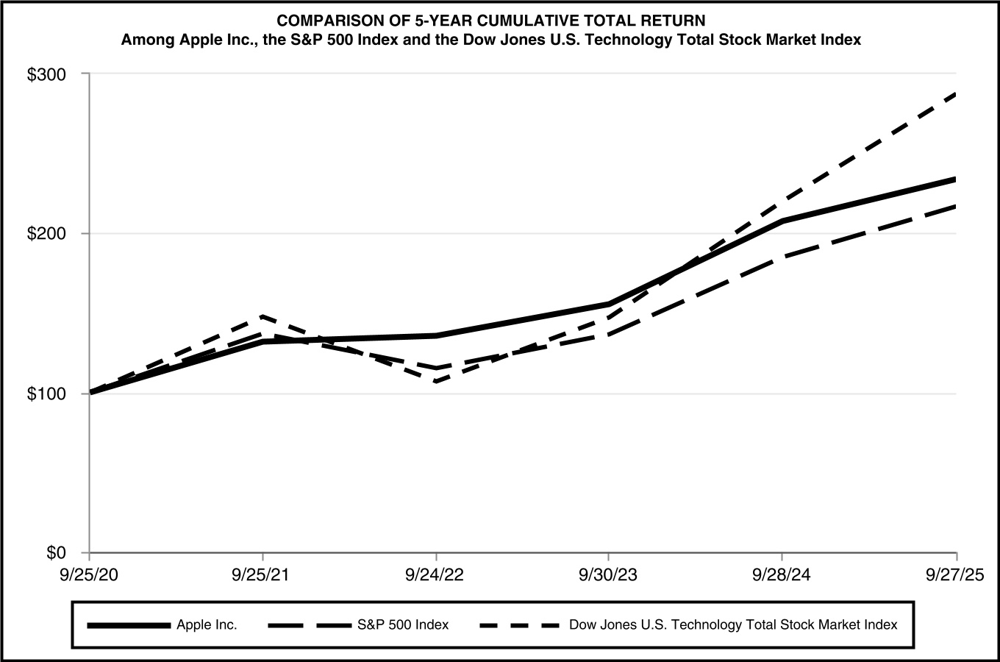

In [19]:
# ============================================================
# CELL 16b: Alternative — display using Colab's built-in
# ============================================================

from IPython.display import display
from PIL import Image

idx = 0
img_info = all_image_paths[idx]
img = Image.open(img_info['path'])
img.thumbnail((1000, 1000))

print(f"Image {idx}: {img_info['ticker']} | {img_info['type']} | {img_info['filename']}")
display(img)

In [20]:
from PIL import Image
import os
import json
from collections import Counter

def classify_image(img_path, img_info):
    try:
        img = Image.open(img_path)
        w, h = img.size
    except Exception:
        return 'reject', 'cannot_open'

    filename = os.path.basename(img_path).lower()
    area = w * h
    img_type = img_info.get('type', 'unknown')

    reject_keywords = ['logo', 'signature', 'header', 'footer', 'icon', 'portrait', 'headshot']
    positive_keywords = [
        'income', 'balance', 'cash', 'revenue', 'assets', 'liabilities',
        'operations', 'earnings', 'financial', 'quarter', 'segment', 'sales'
    ]

    if w < 300 or h < 200:
        return 'reject', 'too_small'

    if area < 120000:
        return 'reject', 'low_area'

    if w > 4 * h:
        return 'reject', 'banner_ratio'

    if h > 5 * w:
        return 'reject', 'sidebar_ratio'

    if any(kw in filename for kw in reject_keywords):
        return 'reject', 'filename_hint_reject'

    has_positive_hint = any(kw in filename for kw in positive_keywords)

    if img_type == 'table':
        if w >= 500 and h >= 250:
            return 'keep', 'large_table' if not has_positive_hint else 'financial_table_hint'
        elif w >= 350 and h >= 200:
            return 'maybe', 'medium_table'
        else:
            return 'reject', 'small_table'

    if img_type == 'chart':
        if w >= 500 and h >= 350:
            return 'keep', 'large_chart' if not has_positive_hint else 'financial_chart_hint'
        elif w >= 350 and h >= 250:
            return 'maybe', 'medium_chart'
        else:
            return 'reject', 'small_chart'

    return 'maybe', 'unclassified'

In [21]:
# --- Run classification ---
print("Classifying images...")
print("=" * 60)

keep_images = []
reject_images = []
maybe_images = []

for img_info in all_image_paths:
    label, reason = classify_image(img_info['path'], img_info)

    entry = {**img_info, 'label': label, 'reason': reason}

    if label == 'keep':
        keep_images.append(entry)
    elif label == 'reject':
        reject_images.append(entry)
    else:
        maybe_images.append(entry)

print(f"\nResults:")
print(f"  KEEP:   {len(keep_images)}")
print(f"  MAYBE:  {len(maybe_images)}")
print(f"  REJECT: {len(reject_images)}")

# Breakdown
print(f"\nKEEP breakdown:")
keep_tables = [x for x in keep_images if x['type'] == 'table']
keep_charts = [x for x in keep_images if x['type'] == 'chart']
print(f"  Tables: {len(keep_tables)}")
print(f"  Charts: {len(keep_charts)}")

print(f"\nREJECT reasons:")
from collections import Counter
reasons = Counter(x['reason'] for x in reject_images)
for reason, count in reasons.most_common():
    print(f"  {reason}: {count}")

print(f"\nBy company (KEEP only):")
for ticker in all_filings.keys():
    count = sum(1 for x in keep_images if x['ticker'] == ticker)
    print(f"  {ticker}: {count}")

# Save the filtered list
filtered_path = os.path.join(cfg.FINANCIAL_ANNOT, 'filtered_images.json')
with open(filtered_path, 'w') as f:
    json.dump({
        'keep': [{k: v for k, v in x.items()} for x in keep_images],
        'maybe': [{k: v for k, v in x.items()} for x in maybe_images],
        'reject': [{k: v for k, v in x.items()} for x in reject_images],
    }, f, indent=2)
print(f"\n✓ Saved to {filtered_path}")

Classifying images...

Results:
  KEEP:   189
  MAYBE:  17
  REJECT: 5

KEEP breakdown:
  Tables: 150
  Charts: 39

REJECT reasons:
  banner_ratio: 3
  low_area: 1
  too_small: 1

By company (KEEP only):
  AAPL: 16
  JPM: 27
  MSFT: 15
  GS: 17
  BAC: 19
  WMT: 16
  JNJ: 20
  XOM: 28
  AMZN: 15
  TSLA: 16

✓ Saved to /content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/filtered_images.json


In [22]:
# ============================================================
# CELL 18: Auto-generate QA pairs from table content
# ============================================================

from bs4 import BeautifulSoup
import re
import json
import random
import os

random.seed(42)

def extract_table_data(html_path, table_index):
    """Extract structured data from a specific table in the HTML."""
    with open(html_path, 'r', encoding='utf-8') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')

    tables = soup.find_all('table')

    # Financial keyword filter (same as Cell 13)
    keywords = [
        'revenue', 'income', 'loss', 'assets', 'liabilities',
        'equity', 'cash', 'earnings', 'shares', 'operating',
        'total', 'net', 'gross', 'expenses', 'depreciation',
        'amortization', 'dividend', 'balance sheet', 'stockholder',
        'comprehensive', 'segment', 'interest', 'tax', 'debt',
        'receivable', 'inventory', 'goodwill', 'impairment'
    ]

    financial_tables = []
    for table in tables:
        text = table.get_text(' ', strip=True).lower()
        if len(text) < 100:
            continue
        keyword_hits = sum(1 for kw in keywords if kw in text)
        if keyword_hits < 2:
            continue
        if not any(c.isdigit() for c in text):
            continue
        financial_tables.append(table)

    if table_index >= len(financial_tables):
        return None

    table = financial_tables[table_index]

    # Parse into rows
    rows = []
    for tr in table.find_all('tr'):
        cells = [td.get_text(' ', strip=True) for td in tr.find_all(['td', 'th'])]
        if cells and any(c.strip() for c in cells):
            rows.append([c.strip() for c in cells])

    if len(rows) < 3:
        return None

    return rows


def generate_table_questions(rows, ticker, company_name):
    """Generate QA pairs from parsed table rows."""
    questions = []

    if not rows or len(rows) < 3:
        return questions

    # Try to identify header row and data rows
    header = rows[0]
    data_rows = rows[1:]

    # Clean up: find rows with numbers
    numeric_rows = []
    for row in data_rows:
        has_number = False
        for cell in row:
            cleaned = cell.replace('$', '').replace(',', '').replace('(', '').replace(')', '').replace('%', '').strip()
            try:
                float(cleaned)
                has_number = True
                break
            except ValueError:
                pass
        if has_number and row[0].strip():
            numeric_rows.append(row)

    if not numeric_rows:
        return questions

    # --- EXTRACTIVE questions ---
    for row in random.sample(numeric_rows, min(2, len(numeric_rows))):
        label = row[0].strip()
        if not label or len(label) < 3:
            continue

        # Find a numeric value in the row
        for col_idx in range(1, len(row)):
            cell = row[col_idx].strip()
            cleaned = cell.replace('$', '').replace(',', '').replace('(', '-').replace(')', '').replace('%', '').strip()
            try:
                float(cleaned)
                col_header = header[col_idx].strip() if col_idx < len(header) else ''

                if col_header:
                    q = f"What was the {label} for {col_header}?"
                else:
                    q = f"What was the {label}?"

                questions.append({
                    'question': q,
                    'answer': cell,
                    'type': 'extractive'
                })
                break
            except (ValueError, IndexError):
                continue

    # --- NUMERICAL REASONING questions ---
    for row in numeric_rows[:3]:
        label = row[0].strip()
        values = []
        for col_idx in range(1, len(row)):
            cell = row[col_idx].strip()
            cleaned = cell.replace('$', '').replace(',', '').replace('(', '-').replace(')', '').replace('%', '').strip()
            try:
                val = float(cleaned)
                col_header = header[col_idx].strip() if col_idx < len(header) else f'column {col_idx}'
                values.append((val, cell, col_header))
            except (ValueError, IndexError):
                continue

        if len(values) >= 2:
            v1, orig1, h1 = values[0]
            v2, orig2, h2 = values[1]

            if v1 != 0:
                pct_change = ((v2 - v1) / abs(v1)) * 100
                answer = f"{pct_change:.1f}%"
                q = f"What was the percentage change in {label} from {h1} to {h2}?"
                questions.append({
                    'question': q,
                    'answer': answer,
                    'type': 'numerical_reasoning'
                })
                break

    # --- LAYOUT UNDERSTANDING questions ---
    if len(numeric_rows) >= 3:
        row_idx = min(2, len(numeric_rows) - 1)
        target_row = numeric_rows[row_idx]
        label = target_row[0].strip()

        q = f"What is the line item listed in row {row_idx + 2} of this table?"
        questions.append({
            'question': q,
            'answer': label,
            'type': 'layout_understanding'
        })

    return questions


def generate_chart_questions(ticker, company_name, filename):
    """Generate generic chart interpretation questions."""
    questions = []

    questions.append({
        'question': f"What type of chart is shown in this image?",
        'answer': "",  # needs manual fill
        'type': 'chart_interpretation'
    })

    questions.append({
        'question': f"What is the title or main subject of this chart?",
        'answer': "",  # needs manual fill
        'type': 'chart_interpretation'
    })

    questions.append({
        'question': f"Which category or time period shows the highest value?",
        'answer': "",  # needs manual fill
        'type': 'chart_interpretation'
    })

    return questions


# --- Generate annotations for all KEEP images ---
print("Generating QA pairs...")
print("=" * 60)

annotations = []
total_questions = 0
auto_filled = 0
needs_manual = 0

company_names = {t: info['name'] for t, info in all_filings.items()}

for img_info in keep_images:
    ticker = img_info['ticker']
    company = company_names.get(ticker, ticker)
    img_type = img_info['type']
    filename = img_info['filename']

    questions = []

    if img_type == 'table':
        # Extract table index from filename (e.g., AAPL_table_003.png → index 2)
        match = re.search(r'table_(\d+)', filename)
        if match:
            table_idx = int(match.group(1)) - 1
            html_path = all_html_files.get(ticker)
            if html_path:
                rows = extract_table_data(html_path, table_idx)
                if rows:
                    questions = generate_table_questions(rows, ticker, company)

    elif img_type == 'chart':
        questions = generate_chart_questions(ticker, company, filename)

    entry = {
        'image_path': img_info['path'],
        'ticker': ticker,
        'company': company,
        'image_type': img_type,
        'filename': filename,
        'questions': questions
    }

    for q in questions:
        total_questions += 1
        if q['answer']:
            auto_filled += 1
        else:
            needs_manual += 1

    annotations.append(entry)

# --- Save ---
output = {
    'dataset_info': {
        'name': 'Financial Document VQA Test Set',
        'version': '1.0',
        'source': 'SEC EDGAR 10-K filings (FY2025)',
        'companies': list(all_filings.keys()),
        'total_images': len(annotations),
        'total_questions': total_questions,
    },
    'annotations': annotations
}

annot_path = os.path.join(cfg.FINANCIAL_ANNOT, 'financial_vqa_annotations.json')
with open(annot_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f"\nDone!")
print(f"  Images annotated: {len(annotations)}")
print(f"  Total QA pairs:   {total_questions}")
print(f"  Auto-filled:      {auto_filled} (ready to use)")
print(f"  Needs manual:     {needs_manual} (chart questions)")
print(f"\n✓ Saved to {annot_path}")

# Category breakdown
from collections import Counter
type_counts = Counter()
for entry in annotations:
    for q in entry['questions']:
        type_counts[q['type']] += 1

print(f"\nQuestion type breakdown:")
for qtype, count in type_counts.most_common():
    print(f"  {qtype}: {count}")

Generating QA pairs...

Done!
  Images annotated: 189
  Total QA pairs:   627
  Auto-filled:      510 (ready to use)
  Needs manual:     117 (chart questions)

✓ Saved to /content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/financial_vqa_annotations.json

Question type breakdown:
  extractive: 260
  layout_understanding: 133
  chart_interpretation: 117
  numerical_reasoning: 117


In [23]:
import json
import os

# Load your dataset
annot_path = "/content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/financial_vqa_annotations.json"

with open(annot_path, 'r') as f:
    data = json.load(f)

clean_annotations = []

def is_bad_question(q):
    text = q['question'].lower()
    ans = q['answer']

    # Bad keywords
    bad_keywords = ['item', 'page', 'note', 'executive']

    if any(k in text for k in bad_keywords):
        return True

    # Broken text
    if 'from  to' in text:
        return True

    if 'column' in text:
        return True

    # Bad numerical answers
    if ans in ['-100.0%', '-0.0%', '0.0%']:
        return True

    return False

for entry in data['annotations']:
    new_questions = []

    for q in entry['questions']:
        # Remove layout questions completely
        if q['type'] == 'layout_understanding':
            continue

        if is_bad_question(q):
            continue

        new_questions.append(q)

    # Only keep images that still have questions
    if len(new_questions) > 0:
        entry['questions'] = new_questions
        clean_annotations.append(entry)

# Save cleaned dataset
clean_data = {
    'dataset_info': data['dataset_info'],
    'annotations': clean_annotations
}

clean_path = "/content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/financial_vqa_clean.json"

with open(clean_path, 'w') as f:
    json.dump(clean_data, f, indent=2)

print("✅ Cleaning done!")
print(f"Original images: {len(data['annotations'])}")
print(f"Clean images:    {len(clean_annotations)}")

total_q = sum(len(x['questions']) for x in clean_annotations)
print(f"Total QA pairs after cleaning: {total_q}")

✅ Cleaning done!
Original images: 189
Clean images:    159
Total QA pairs after cleaning: 366


In [24]:
from collections import Counter

with open(clean_path, 'r') as f:
    clean_data = json.load(f)

type_counts = Counter()
for entry in clean_data['annotations']:
    for q in entry['questions']:
        type_counts[q['type']] += 1

print("Question type breakdown (cleaned):")
for qtype, count in type_counts.most_common():
    print(f"  {qtype}: {count}")

Question type breakdown (cleaned):
  extractive: 232
  chart_interpretation: 117
  numerical_reasoning: 17


In [25]:
# ============================================================
# FINAL CLEANING CELL: Make financial_vqa_final.json
# ============================================================

import json
import os
import re
from copy import deepcopy
from collections import Counter

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
clean_path = "/content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/financial_vqa_clean.json"
final_path = "/content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/financial_vqa_final.json"

# ------------------------------------------------------------
# Load cleaned dataset
# ------------------------------------------------------------
with open(clean_path, "r", encoding="utf-8") as f:
    data = json.load(f)

annotations = data["annotations"]

# ------------------------------------------------------------
# Heuristics
# ------------------------------------------------------------
BAD_QUESTION_PATTERNS = [
    r"\bitem\b",
    r"\bpage\b",
    r"\bnote\b",
    r"\bexecutive\b",
    r"\bintroduction\b",
]

BAD_TEXT_SNIPPETS = [
    "from  to",
    "column ",
    "= roi",
]

# Optional stricter removal for non-core financial/personnel-style tables
OPTIONAL_BAD_TERMS = [
    "women",
    "men",
    "total employees",
    "current position held since",
    "age",
    "james dimon",
    "robin leopold",
    "director",
    "executive officer",
]

def normalize_space(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def has_bad_pattern(text: str) -> bool:
    t = text.lower()
    for pat in BAD_QUESTION_PATTERNS:
        if re.search(pat, t):
            return True
    for bad in BAD_TEXT_SNIPPETS:
        if bad in t:
            return True
    return False

def is_broken_answer(ans: str) -> bool:
    if ans is None:
        return True
    a = str(ans).strip()

    if a == "":
        return False  # blank chart answers are allowed for now

    # unmatched parentheses
    if a.count("(") != a.count(")"):
        return True

    # obviously bad placeholder-style answers
    if a in {"-", "--", "nan", "None"}:
        return True

    return False

def is_bad_numerical(q: dict) -> bool:
    if q.get("type") != "numerical_reasoning":
        return False

    ans = str(q.get("answer", "")).strip()
    qtext = q.get("question", "").lower()

    # Remove all numerical questions if you want max safety:
    return True

    # Alternative softer version:
    # if ans in {"-100.0%", "-99.9%", "-99.8%", "-99.4%", "-0.0%", "0.0%"}:
    #     return True
    # if "from  to" in qtext or "column " in qtext:
    #     return True
    # return False

def is_optional_nonfinancial(q: dict) -> bool:
    t = q.get("question", "").lower()
    return any(term in t for term in OPTIONAL_BAD_TERMS)

def canonical_question_key(qtext: str) -> str:
    t = normalize_space(qtext.lower())
    t = t.replace("’", "'")
    return t

def should_drop_question(q: dict) -> bool:
    qtext = str(q.get("question", "")).strip()
    ans = str(q.get("answer", "")).strip()
    qtype = q.get("type", "").strip()

    if qtext == "":
        return True

    if has_bad_pattern(qtext):
        return True

    if is_bad_numerical(q):
        return True

    if is_broken_answer(ans):
        return True

    # Optional stricter financial-only filtering
    if is_optional_nonfinancial(q):
        return True

    # Remove very vague extractive questions like "What was the Products?"
    if qtype == "extractive":
        vague = [
            "what was the products?",
            "what was the total?",
            "what was the credit?",
            "what was the wholesale?",
            "what was the women for total employees?",
            "what was the men for total employees?",
        ]
        if normalize_space(qtext.lower()) in vague:
            return True

    return False

# ------------------------------------------------------------
# Final cleaning
# ------------------------------------------------------------
final_annotations = []
stats = Counter()

for entry in annotations:
    new_entry = deepcopy(entry)
    qs = entry.get("questions", [])

    kept_questions = []
    seen_questions = set()

    for q in qs:
        stats["questions_seen"] += 1

        if should_drop_question(q):
            stats["questions_dropped"] += 1
            stats[f"dropped_type::{q.get('type', 'unknown')}"] += 1
            continue

        # Deduplicate by normalized question text
        qkey = canonical_question_key(q.get("question", ""))
        if qkey in seen_questions:
            stats["duplicates_removed"] += 1
            continue

        seen_questions.add(qkey)

        # Normalize whitespace
        q["question"] = normalize_space(q["question"])
        if isinstance(q.get("answer", None), str):
            q["answer"] = normalize_space(q["answer"])

        kept_questions.append(q)
        stats["questions_kept"] += 1
        stats[f"kept_type::{q.get('type', 'unknown')}"] += 1

    if len(kept_questions) > 0:
        new_entry["questions"] = kept_questions
        final_annotations.append(new_entry)
        stats["images_kept"] += 1
    else:
        stats["images_removed"] += 1

# ------------------------------------------------------------
# Update dataset info
# ------------------------------------------------------------
final_data = deepcopy(data)
final_data["annotations"] = final_annotations
final_data["dataset_info"]["version"] = "1.2"
final_data["dataset_info"]["total_images"] = len(final_annotations)
final_data["dataset_info"]["total_questions"] = sum(len(x["questions"]) for x in final_annotations)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
with open(final_path, "w", encoding="utf-8") as f:
    json.dump(final_data, f, indent=2, ensure_ascii=False)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
type_counts = Counter()
blank_chart_answers = 0
table_count = 0
chart_count = 0

for entry in final_annotations:
    if entry["image_type"] == "table":
        table_count += 1
    elif entry["image_type"] == "chart":
        chart_count += 1

    for q in entry["questions"]:
        type_counts[q["type"]] += 1
        if q["type"] == "chart_interpretation" and str(q.get("answer", "")).strip() == "":
            blank_chart_answers += 1

print("✅ Final cleaning done!")
print("=" * 60)
print(f"Final images:            {len(final_annotations)}")
print(f"Final QA pairs:          {final_data['dataset_info']['total_questions']}")
print(f"Tables:                  {table_count}")
print(f"Charts:                  {chart_count}")
print(f"Blank chart answers:     {blank_chart_answers}")
print()
print("Question type breakdown:")
for k, v in type_counts.most_common():
    print(f"  {k}: {v}")
print()
print("Cleaning stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")
print()
print(f"✓ Saved to: {final_path}")

✅ Final cleaning done!
Final images:            146
Final QA pairs:          256
Tables:                  107
Charts:                  39
Blank chart answers:     78

Question type breakdown:
  extractive: 178
  chart_interpretation: 78

Cleaning stats:
  questions_seen: 366
  questions_dropped: 107
  dropped_type::chart_interpretation: 39
  questions_kept: 256
  kept_type::chart_interpretation: 78
  images_kept: 146
  kept_type::extractive: 178
  duplicates_removed: 3
  dropped_type::numerical_reasoning: 17
  dropped_type::extractive: 51
  images_removed: 13

✓ Saved to: /content/drive/MyDrive/FinDocVQA/data/financial_test/annotations/financial_vqa_final.json
